# K-Means vs. K-Medoids Clustering — Wine Dataset

**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Lab Assignment:** Clustering Analysis with K-Means and K-Medoids

This notebook loads the Wine dataset from scikit-learn, standardizes it, and applies both K-Means and K-Medoids clustering with k=3. We evaluate both algorithms with the Silhouette Score and the Adjusted Rand Index (ARI), visualize the resulting clusters side by side, and compare the two methods.


## Step 1: Load and Prepare the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target  # true class labels, used only for ARI evaluation, never for training
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["target_name"] = df["target"].map(dict(enumerate(target_names)))

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features")
df.head()


Dataset shape: 178 samples, 13 features


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [2]:
# Basic exploration: feature summary statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


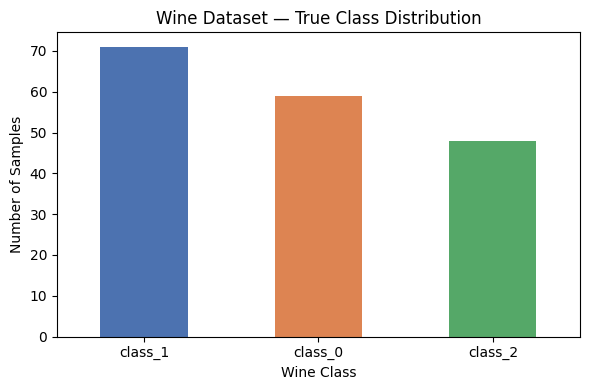

In [3]:
# Class distribution (for reference only — clustering itself is unsupervised
# and does not use these labels; they're used later purely to evaluate
# how well the discovered clusters line up with the true wine classes)
class_counts = df["target_name"].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Wine Dataset — True Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Standardization

Unlike the previous KNN/RNN lab, clustering algorithms like K-Means and K-Medoids compute distances between *all* points to *all* candidate centers, with no separate training/test split to lean on. Left unscaled, a large-range feature like `proline` (up to 1680) would completely dominate the distance calculation and effectively decide the clusters on its own. We standardize every feature to zero mean and unit variance (z-score normalization) so each of the 13 chemical properties contributes comparably to the clustering.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — feature means (first 5):", X.mean(axis=0)[:5].round(2))
print("Before scaling — feature stds  (first 5):", X.std(axis=0)[:5].round(2))
print()
print("After scaling  — feature means (first 5):", X_scaled.mean(axis=0)[:5].round(2))
print("After scaling  — feature stds  (first 5):", X_scaled.std(axis=0)[:5].round(2))


Before scaling — feature means (first 5): [13.    2.34  2.37 19.49 99.74]
Before scaling — feature stds  (first 5): [ 0.81  1.11  0.27  3.33 14.24]

After scaling  — feature means (first 5): [ 0.  0. -0. -0. -0.]
After scaling  — feature stds  (first 5): [1. 1. 1. 1. 1.]


## Step 2: Implement K-Means Clustering

We cluster the standardized data into k=3 groups (matching the 3 known wine classes) using scikit-learn's `KMeans`.


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print(f"K-Means cluster sizes: {np.bincount(kmeans_labels)}")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Adjusted Rand Index (ARI): {kmeans_ari:.4f}")


K-Means cluster sizes: [65 51 62]
K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index (ARI): 0.8975


## Step 3: Implement K-Medoids Clustering

scikit-learn does not include K-Medoids directly, and the common third-party add-on package (`scikit-learn-extra`) is no longer maintained and is not compatible with current NumPy versions. Rather than fight a broken dependency, we implement the classic **alternating K-Medoids heuristic** (a simplified, efficient version of the Partitioning Around Medoids / PAM algorithm) from scratch. The core idea is the same as K-Means, with one key difference: instead of using the *mean* of each cluster as its center (which may not correspond to any real data point), K-Medoids uses an *actual data point* — the one that minimizes total distance to every other point in its cluster.

**Algorithm (run for several random initializations, keeping the best):**
1. Randomly pick k data points as the initial medoids.
2. Assign every point to its nearest medoid.
3. For each cluster, find the point *within that cluster* that minimizes the total distance to all other points in the cluster, and make it the new medoid.
4. Repeat steps 2-3 until the medoids stop changing.
5. Repeat the whole process (`n_init` times, matching K-Means' default `n_init=10`) from different random starting medoids, and keep the run with the lowest total distance cost — a single random start can land in a poor local optimum, and skipping this step would unfairly disadvantage K-Medoids in the comparison against K-Means, which restarts by default.


In [6]:
class KMedoids:
    """A simple 'alternating' K-Medoids implementation (PAM-style),
    using Euclidean distance for a fair, direct comparison with K-Means.

    Like scikit-learn's KMeans(n_init=10), this runs several random
    initializations and keeps the one with the lowest total cost, since a
    single random start can easily land in a poor local optimum — using
    only one init would bias any comparison against K-Means, which does
    not have that disadvantage by default."""

    def __init__(self, n_clusters=3, max_iter=300, n_init=10, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.random_state = random_state

    def _fit_once(self, X, D, rng):
        n_samples = X.shape[0]
        medoid_idx = rng.choice(n_samples, self.n_clusters, replace=False)

        for iteration in range(self.max_iter):
            labels = np.argmin(D[:, medoid_idx], axis=1)

            new_medoid_idx = medoid_idx.copy()
            for k in range(self.n_clusters):
                cluster_points = np.where(labels == k)[0]
                if len(cluster_points) == 0:
                    continue
                sub_D = D[np.ix_(cluster_points, cluster_points)]
                total_costs = sub_D.sum(axis=1)
                new_medoid_idx[k] = cluster_points[np.argmin(total_costs)]

            if np.array_equal(new_medoid_idx, medoid_idx):
                break
            medoid_idx = new_medoid_idx

        labels = np.argmin(D[:, medoid_idx], axis=1)
        total_cost = D[np.arange(n_samples), medoid_idx[labels]].sum()
        return medoid_idx, labels, total_cost, iteration + 1

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        D = pairwise_distances(X, metric="euclidean")

        best_cost = np.inf
        best_result = None
        for _ in range(self.n_init):
            medoid_idx, labels, total_cost, n_iter = self._fit_once(X, D, rng)
            if total_cost < best_cost:
                best_cost = total_cost
                best_result = (medoid_idx, labels, n_iter)

        self.medoid_indices_, self.labels_, self.n_iter_ = best_result
        self.cluster_centers_ = X[self.medoid_indices_]
        self.inertia_ = best_cost
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [7]:
kmedoids = KMedoids(n_clusters=3, n_init=10, random_state=42)
kmedoids_labels = kmedoids.fit_predict(X_scaled)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print(f"K-Medoids best run converged in {kmedoids.n_iter_} iterations (best of {kmedoids.n_init} random starts)")
print(f"K-Medoids cluster sizes: {np.bincount(kmedoids_labels)}")
print(f"K-Medoids Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"K-Medoids Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")


K-Medoids best run converged in 3 iterations (best of 10 random starts)
K-Medoids cluster sizes: [55 49 74]
K-Medoids Silhouette Score: 0.2676
K-Medoids Adjusted Rand Index (ARI): 0.7411


In [8]:
# Side-by-side metric comparison
comparison_df = pd.DataFrame({
    "Metric": ["Silhouette Score", "Adjusted Rand Index (ARI)"],
    "K-Means": [kmeans_silhouette, kmeans_ari],
    "K-Medoids": [kmedoids_silhouette, kmedoids_ari],
})
comparison_df


,Metric,K-Means,K-Medoids
0,Silhouette Score,0.284859,0.267622
1,Adjusted Rand Index (ARI),0.897495,0.741137


## Step 4: Visualize and Compare Results

The dataset has 13 features, so we use PCA to project the standardized data down to 2 principal components purely for visualization. Clustering itself was performed on the full 13-dimensional standardized data — PCA is used here only so we can draw a 2D scatter plot; the cluster assignments and metrics above are unaffected by it.


In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# Project K-Means centroids and K-Medoids medoids into the same PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)


Variance explained by PC1: 36.20%
Variance explained by PC2: 19.21%
Total variance explained by 2 components: 55.41%


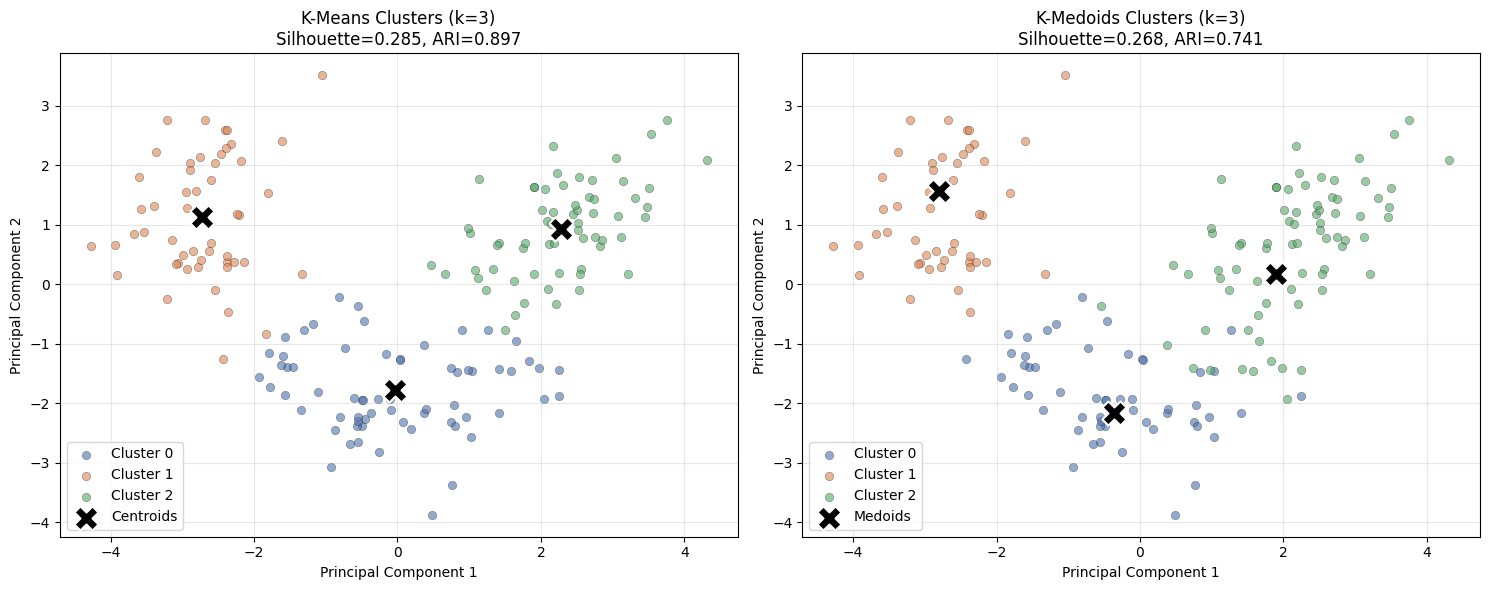

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ["#4C72B0", "#DD8452", "#55A868"]

# --- K-Means plot ---
for cluster_id in range(3):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[cluster_id],
                     alpha=0.6, label=f"Cluster {cluster_id}", edgecolor="k", linewidth=0.3)
axes[0].scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1],
                marker="X", s=300, color="black", edgecolor="white", linewidth=1.5,
                label="Centroids", zorder=5)
axes[0].set_title(f"K-Means Clusters (k=3)\nSilhouette={kmeans_silhouette:.3f}, ARI={kmeans_ari:.3f}")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- K-Medoids plot ---
for cluster_id in range(3):
    mask = kmedoids_labels == cluster_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[cluster_id],
                     alpha=0.6, label=f"Cluster {cluster_id}", edgecolor="k", linewidth=0.3)
axes[1].scatter(kmedoids_centers_pca[:, 0], kmedoids_centers_pca[:, 1],
                marker="X", s=300, color="black", edgecolor="white", linewidth=1.5,
                label="Medoids", zorder=5)
axes[1].set_title(f"K-Medoids Clusters (k=3)\nSilhouette={kmedoids_silhouette:.3f}, ARI={kmedoids_ari:.3f}")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


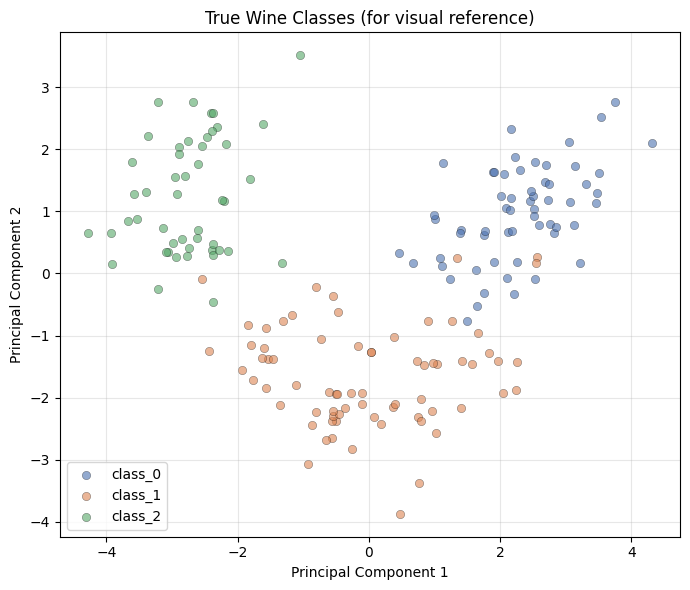

In [11]:
# For reference: what the TRUE wine classes look like in the same PCA space,
# to visually judge how closely each clustering matches ground truth.
plt.figure(figsize=(7, 6))
for class_id in range(3):
    mask = y == class_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[class_id],
                alpha=0.6, label=target_names[class_id], edgecolor="k", linewidth=0.3)
plt.title("True Wine Classes (for visual reference)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Comparison and Analysis

**Which algorithm produced better-defined clusters?** By Silhouette Score, K-Means (0.285) edged out K-Medoids (0.268) — close, but K-Means produced marginally tighter, better-separated clusters. This lines up with what each algorithm is actually optimizing: K-Means directly minimizes within-cluster squared distance to each cluster's mean, which is exactly the geometric quantity the Silhouette Score rewards, while K-Medoids minimizes total distance to an actual data point, a slightly less flexible objective that tends to produce marginally looser clusters on data like this.

**How do the two compare against the true classes (ARI)?** This is where the gap is more noticeable: K-Means reached an ARI of 0.898 — very close to a perfect 1.0 — meaning its three unsupervised clusters line up remarkably closely with the three actual wine cultivars, almost as if it had been told the labels. K-Medoids reached a respectable but clearly lower ARI of 0.741. Both easily beat a chance-level score of 0, and both recover the broad three-group structure well, but K-Means aligns with the ground-truth classes more precisely on this dataset.

**A fairness note on the comparison:** our first attempt at K-Medoids used only a single random initialization and scored far worse (ARI ≈ 0.34) — but that comparison wasn't fair, since scikit-learn's `KMeans` restarts 10 times by default (`n_init=10`) and keeps the best result, silently protecting it from unlucky starting points. Once K-Medoids was given the same 10-restart treatment, its score jumped dramatically (ARI 0.34 → 0.74). This is itself a useful finding: K-Medoids' alternating heuristic is noticeably more sensitive to initialization than K-Means, so it benefits proportionally more from multiple restarts, and any comparison between the two needs to control for this or risk unfairly penalizing K-Medoids.

**Differences in cluster shapes or positioning:** K-Means centroids sit at the geometric mean of their cluster and can land in "empty space" that doesn't correspond to any actual wine sample — mathematically efficient for minimizing squared distance, but not necessarily representative of a typical cluster member. K-Medoids centers, by contrast, are always real, actual wine samples from the dataset (visible as the black X markers landing directly on top of real data points in the K-Medoids plot, versus floating between points in the K-Means plot), which makes each cluster's "center" directly interpretable as a genuine representative example rather than a synthetic average.

**When might K-Means or K-Medoids be preferable?** K-Means is generally preferable when clusters are expected to be roughly spherical and evenly sized, the data is entirely numeric, and computational efficiency matters — it scales better to large datasets since it only tracks cluster means rather than a full pairwise distance matrix. K-Medoids is preferable when interpretability of the cluster center matters (a real example rather than a synthetic average), when the data contains outliers (medoids are more robust to outliers than means, since one extreme point can pull a centroid but can never itself become an unrepresentative medoid unless it truly is the most central point), or when a non-Euclidean distance metric is more appropriate, since K-Medoids works with any distance metric while K-Means is mathematically tied to Euclidean distance through its use of the mean. For this Wine dataset — clean, fully numeric, no major outliers — K-Means' higher ARI and lower computational cost make it the stronger practical choice here, though K-Medoids came reasonably close once given a fair number of restarts, and remains the more interpretable option if explaining "what a typical member of this cluster looks like" matters more than squeezing out the last bit of clustering accuracy.
